Epoch 0, Loss: 0.541986
Epoch 500, Loss: 0.026328
Epoch 1000, Loss: 0.005712
Epoch 1500, Loss: 0.001430
Epoch 2000, Loss: 0.000421
Epoch 2500, Loss: 0.000612
Epoch 3000, Loss: 0.000621
Epoch 3500, Loss: 0.000090
Epoch 4000, Loss: 0.000070
Epoch 4500, Loss: 0.000058


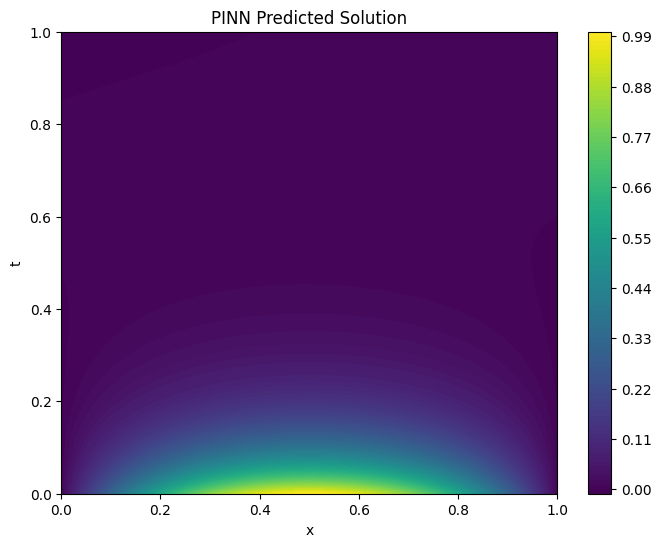

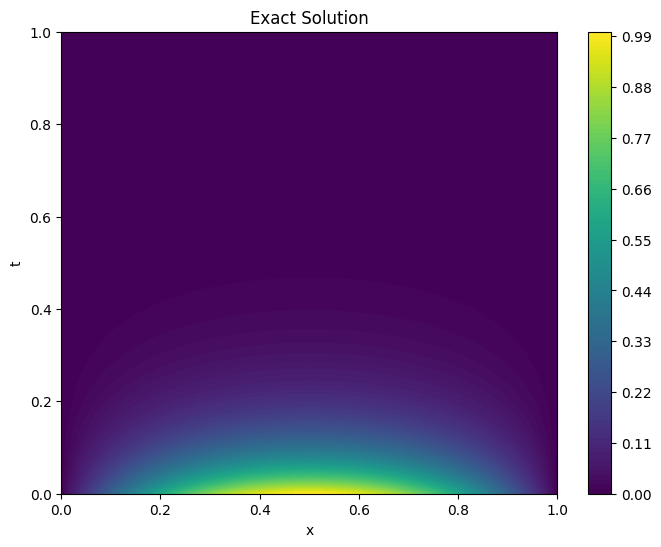

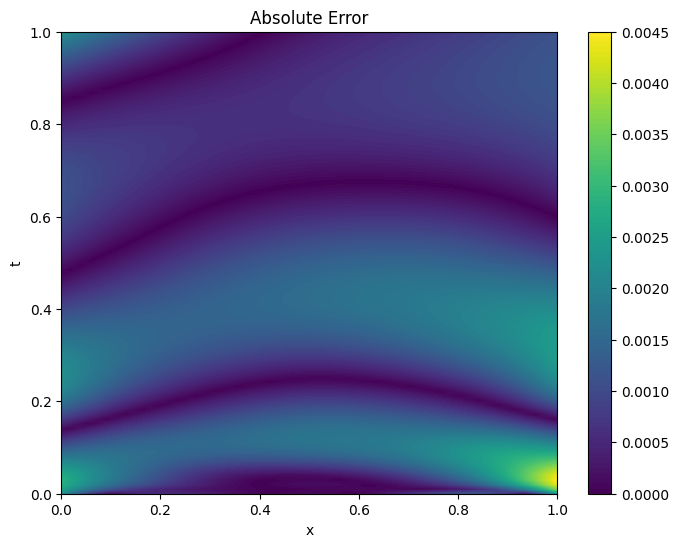

In [1]:
# Physics-Informed Neural Network (PINN)
# Solving the 1D Heat Equation:
#
#     ∂u/∂t = ∂²u/∂x²
#
# Domain:
#     x ∈ [0,1]
#     t ∈ [0,1]
#
# Boundary Conditions:
#     u(0,t) = 0
#     u(1,t) = 0
#
# Initial Condition:
#     u(x,0) = sin(πx)
#
# Exact Solution:
#     u(x,t) = exp(-π²t) sin(πx)

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Neural Network
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(2, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 1)
        )

    def forward(self, x, t):
        inputs = torch.cat([x, t], dim=1)
        return self.network(inputs)

model = PINN().to(device)

# PDE Residual
def pde_residual(model, x, t):

    x.requires_grad_(True)
    t.requires_grad_(True)

    u = model(x, t)

    u_t = torch.autograd.grad(
        u,
        t,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    u_x = torch.autograd.grad(
        u,
        x,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    u_xx = torch.autograd.grad(
        u_x,
        x,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True
    )[0]

    residual = u_t - u_xx

    return residual

# Training Points

N_f = 10000   # Collocation points
N_b = 200     # Boundary points
N_i = 200     # Initial points

# Collocation Points
x_f = torch.rand((N_f, 1), device=device)
t_f = torch.rand((N_f, 1), device=device)

# Boundary Points
t_b = torch.rand((N_b, 1), device=device)

x_b0 = torch.zeros((N_b, 1), device=device)
x_b1 = torch.ones((N_b, 1), device=device)

# Initial Points
x_i = torch.rand((N_i, 1), device=device)
t_i = torch.zeros((N_i, 1), device=device)

u_i = torch.sin(np.pi * x_i)

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training
epochs = 5000

for epoch in range(epochs):

    optimizer.zero_grad()

    # PDE Loss
    f = pde_residual(model, x_f, t_f)
    loss_pde = torch.mean(f**2)

    # Boundary Loss
    u_b0 = model(x_b0, t_b)
    u_b1 = model(x_b1, t_b)

    loss_bc = torch.mean(u_b0**2) + torch.mean(u_b1**2)

    # Initial Loss
    u_pred_i = model(x_i, t_i)
    loss_ic = torch.mean((u_pred_i - u_i)**2)

    # Total Loss
    loss = loss_pde + loss_bc + loss_ic

    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

# Visualization

x = np.linspace(0, 1, 100)
t = np.linspace(0, 1, 100)

X, T = np.meshgrid(x, t)

XT = np.hstack((X.flatten()[:, None], T.flatten()[:, None]))

x_test = torch.tensor(XT[:, 0:1], dtype=torch.float32).to(device)
t_test = torch.tensor(XT[:, 1:2], dtype=torch.float32).to(device)

with torch.no_grad():
    u_pred = model(x_test, t_test)

U_pred = u_pred.cpu().numpy().reshape(100, 100)

# Exact Solution
U_exact = np.exp(-np.pi**2 * T) * np.sin(np.pi * X)

# Plot Predicted Solution
plt.figure(figsize=(8,6))
plt.contourf(X, T, U_pred, 100)
plt.colorbar()
plt.xlabel("x")
plt.ylabel("t")
plt.title("PINN Predicted Solution")
plt.show()

# Plot Exact Solution
plt.figure(figsize=(8,6))
plt.contourf(X, T, U_exact, 100)
plt.colorbar()
plt.xlabel("x")
plt.ylabel("t")
plt.title("Exact Solution")
plt.show()

# Error
error = np.abs(U_exact - U_pred)

plt.figure(figsize=(8,6))
plt.contourf(X, T, error, 100)
plt.colorbar()
plt.xlabel("x")
plt.ylabel("t")
plt.title("Absolute Error")
plt.show()
